# Experimenting with Joins

In [2]:
# Experimenting with one-to-one and one-to-many joins
import pandas as pd

# Make up two toy dataframes
data1 = {
    'A' : ['a1','a2'],
    'B' : ['b1','b2'],
}
data2 = {
    'B' : ['b1','b3'],
    'C' : ['c1','c2'],
}

df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)

# Now, in theory, if I merge these two, I *think* I should get something with only one row if I merge df2 onto df1
df1.merge(df2,on="B")

,A,B,C
0,a1,b1,c1


In [2]:
#Okay, that went as expected. Now, let's modify it and test a one-to-many join
# Make up two toy dataframes
data1 = {
    'A' : ['a1','a2'],
    'B' : ['b1','b2'],
}
data2 = {
    'B' : ['b1','b1', 'b2'],
    'C' : ['c1','c2', 'c3'],
}

df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)

# If I merge these two now, I should get something with 3 rows... I think?
df1.merge(df2,on="B")

,A,B,C
0,a1,b1,c1
1,a1,b1,c2
2,a2,b2,c3


# Practical Example
Based on the example shown in the "merging multiple tables" DataCamp video

In [3]:
import kagglehub
#grab files
path1 = kagglehub.dataset_download("chicago/chicago-small-business-improvement-fund-grants")
path2 = kagglehub.dataset_download("chicago/chicago-business-licenses-and-owners")
path3 = kagglehub.dataset_download("aungdev/chicago-ward-offices", path="Chicago_Ward_Offices.csv")
grants = pd.read_csv(path1+"\\small-business-improvement-fund-sbif-grant-agreements.csv")
licenses= pd.read_csv(path2+"\\business-licenses.csv")
wards = pd.read_csv(path3)

C:\Users\lucfi\miniconda3\envs\datacamp\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
C:\Users\lucfi\miniconda3\envs\datacamp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\lucfi\AppData\Local\Temp\ipykernel_49252\2957862100.py:7: DtypeWarning: Columns (0: ZIP CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  licenses= pd.read_csv(path2+"\\business-licenses.csv")


In [4]:
print("Grants \n", grants.columns)
print("Wards \n", wards.columns)
print("Licenses \n", licenses.columns)

Grants 
 Index(['Company', 'Address', 'TIF District', 'Completion Date', 'Actual Costs',
       'Actual Grant', 'Work Items'],
      dtype='str')
Wards 
 Index(['WARD', 'ALDERMAN', 'ADDRESS', 'CITY', 'STATE', 'ZIPCODE', 'LOCATION',
       'CITY HALL ADDRESS', 'CITY HALL CITY', 'CITY HALL STATE',
       'CITY HALL ZIPCODE', 'CITY HALL PHONE'],
      dtype='str')
Licenses 
 Index(['ID', 'LICENSE ID', 'ACCOUNT NUMBER', 'SITE NUMBER', 'LEGAL NAME',
       'DOING BUSINESS AS NAME', 'ADDRESS', 'CITY', 'STATE', 'ZIP CODE',
       'WARD', 'PRECINCT', 'WARD PRECINCT', 'POLICE DISTRICT', 'LICENSE CODE',
       'LICENSE DESCRIPTION', 'BUSINESS ACTIVITY ID', 'BUSINESS ACTIVITY',
       'LICENSE NUMBER', 'APPLICATION TYPE', 'APPLICATION CREATED DATE',
       'APPLICATION REQUIREMENTS COMPLETE', 'PAYMENT DATE',
       'CONDITIONAL APPROVAL', 'LICENSE TERM START DATE',
       'LICENSE TERM EXPIRATION DATE', 'LICENSE APPROVED FOR ISSUANCE',
       'DATE ISSUED', 'LICENSE STATUS', 'LICENSE STATUS CHANG

In [4]:
# grants.merge(licenses,on="Address")
# This will produce an error, not surprising. Licenses uses all-caps for address! Grants is the odd one out here.
# Need to change the columns to uppercase!
grants.columns = grants.columns.str.upper()
grants_licenses=grants.merge(licenses, on="ADDRESS")
print(grants_licenses)
# Note from later: This produces an empty set because the literal text doesn't match. 

Empty DataFrame
Columns: [COMPANY, ADDRESS, TIF DISTRICT, COMPLETION DATE, ACTUAL COSTS, ACTUAL GRANT, WORK ITEMS, ID, LICENSE ID, ACCOUNT NUMBER, SITE NUMBER, LEGAL NAME, DOING BUSINESS AS NAME, CITY, STATE, ZIP CODE, WARD, PRECINCT, WARD PRECINCT, POLICE DISTRICT, LICENSE CODE, LICENSE DESCRIPTION, BUSINESS ACTIVITY ID, BUSINESS ACTIVITY, LICENSE NUMBER, APPLICATION TYPE, APPLICATION CREATED DATE, APPLICATION REQUIREMENTS COMPLETE, PAYMENT DATE, CONDITIONAL APPROVAL, LICENSE TERM START DATE, LICENSE TERM EXPIRATION DATE, LICENSE APPROVED FOR ISSUANCE, DATE ISSUED, LICENSE STATUS, LICENSE STATUS CHANGE DATE, SSA, LATITUDE, LONGITUDE, LOCATION, Community Areas, Historical Wards 2003-2015, Zip Codes, Census Tracts, Wards]
Index: []

[0 rows x 45 columns]


In [6]:
# Check for intersections. Maybe there's no overlap?
list(set(grants["COMPANY"].str.upper()) & set(licenses["LEGAL NAME"].str.upper()))

['MICHELLE LYTLE PHOTOGRAPHY',
 'BLUE BOX, INC.',
 'TYLKA PRINTING INC.',
 'RB SIGN & DESIGN INC',
 'ECOLIT INC.',
 'J.C. MOON CO.',
 'ANTEK MADISON PLASTICS USA LTD.',
 'MYONG YUL KIM',
 'KIM LONG 2 INC.',
 'MR FROG CAR WASH, INC.',
 'JEFFERY MANOR AUTO WASH INC',
 'PANCHO III CORPORATION',
 'STEINER INDUSTRIES',
 'EXOTIC CREATIONS INC',
 'MABES DELI INCORPORATED',
 'GATEWAY TO LEARNING',
 'DINA NOVILLO',
 'BUCKEYE CONSTRUCTION CO., INC.',
 'JUAN MARTINEZ',
 'DOVETAIL BREWERY, INC.',
 'BUILDING BLOCKS INC',
 'LIZ-NEY-LAND LEARNING CENTER, INC.',
 'TIME TREASURERS ANTIQUES, INC.',
 "CHICAGO'S INDOOR GARDEN, INC.",
 'PARK PLACE PROPERTIES I, LLC',
 'ELGIN SWEEPING SERVICES, INC.',
 'MODERN PROCESS EQUIPMENT, INC.',
 'SHAN FOOD CORPORATION',
 'SUHLAND COIN LAUNDRY, INC.',
 'THE MIRACLE CENTER, INC.',
 'TRES JOLIE ART INC',
 'ABBEY METAL SERVICES, INC.',
 'RICKARD CIRCULAR FOLDING COMPANY',
 'CENTURY PLATING CO INC',
 'JUSTIN BLAIR & COMPANY',
 'SKETCHPAD INC.',
 'CHROMIUM INDUSTRIES, LLC

In [7]:
# Clearly there is overlap, but the address match didn't work. Maybe it's just because of case?
list(set(grants["ADDRESS"].str.upper()) & set(licenses["ADDRESS"].str.upper()))

['9031 S STONY ISLAND AVE',
 '4619 N BROADWAY',
 '3033 W 111TH ST',
 '1511 S PULASKI RD',
 '4823 W IRVING PARK RD',
 '4801 N BROADWAY',
 '6226 N BROADWAY',
 '2544 E 95TH ST',
 '1017 W WASHINGTON BLVD',
 '5015 N WESTERN AVE',
 '1511 W 38TH ST',
 '3940 N CICERO AVE',
 '4401 W ROOSEVELT RD',
 '945 E 93RD ST',
 '4437 N BROADWAY',
 '1206 E 53RD ST',
 '6843 W 60TH PL',
 '3414 W NORTH AVE',
 '3958 W 58TH PL',
 '10240 S EWING AVE',
 '2940 N CICERO AVE',
 '1000 W FULTON MARKET',
 '4707 N BROADWAY',
 '3333 W 111TH ST',
 '5900 N BROADWAY',
 '5860 N PULASKI RD',
 '4821 N PULASKI RD',
 '1300 N WESTERN AVE',
 '4661 N BROADWAY',
 '112 N GREEN ST',
 '5430 N BROADWAY',
 '833 W RANDOLPH ST',
 '2620 W FLETCHER ST',
 '10232 S EWING AVE',
 '2385 N MILWAUKEE AVE',
 '3915 W FULLERTON AVE',
 '9900 S WESTERN AVE',
 '5000 W ROOSEVELT RD',
 '2323 N PULASKI RD']

In [5]:
# Overlap in address as well. Seems like I need to just make sure everything has the same case then!
for col in grants.select_dtypes(include=['str']):
    grants[col] = grants[col].str.upper()

for col in grants.select_dtypes(include=['str']):
    grants[col] = grants[col].str.upper()

In [6]:
# Rename "COMPANY" in grants to "LEGAL NAME" to match licenses
grants.rename(columns={"COMPANY":"LEGAL NAME"},inplace=True)

In [7]:
grants_licenses=grants.merge(licenses, on="LEGAL NAME")
grants_licenses.head()

,LEGAL NAME,ADDRESS_x,TIF DISTRICT,COMPLETION DATE,ACTUAL COSTS,ACTUAL GRANT,WORK ITEMS,ID,LICENSE ID,ACCOUNT NUMBER,...,LICENSE STATUS CHANGE DATE,SSA,LATITUDE,LONGITUDE,LOCATION,Community Areas,Historical Wards 2003-2015,Zip Codes,Census Tracts,Wards
0,MARCO LIGHTING COMPONENTS INC,457 N LEAVITT,KINZIE INDUSTRIAL CORRIDOR INDUSTRIAL CORRIDOR,2002-01-04T00:00:00.000,104552.0,50000.0,GUTTER-FLASHING. ROOF / TUCKPOINTING / ELECTRI...,11321-20071116,1849348,5292,...,NaN,NaN,41.890234,-87.681641,"{'latitude': '41.89023352056889', 'longitude':...",25.0,10.0,21184.0,547.0,46.0
1,MARCO LIGHTING COMPONENTS INC,457 N LEAVITT,KINZIE INDUSTRIAL CORRIDOR INDUSTRIAL CORRIDOR,2002-01-04T00:00:00.000,104552.0,50000.0,GUTTER-FLASHING. ROOF / TUCKPOINTING / ELECTRI...,11321-20051116,1624181,5292,...,NaN,NaN,41.890234,-87.681641,"{'latitude': '41.89023352056889', 'longitude':...",25.0,10.0,21184.0,547.0,46.0
2,MARCO LIGHTING COMPONENTS INC,457 N LEAVITT,KINZIE INDUSTRIAL CORRIDOR INDUSTRIAL CORRIDOR,2002-01-04T00:00:00.000,104552.0,50000.0,GUTTER-FLASHING. ROOF / TUCKPOINTING / ELECTRI...,11321-20031116,1426987,5292,...,NaN,NaN,41.890234,-87.681641,"{'latitude': '41.89023352056889', 'longitude':...",25.0,10.0,21184.0,547.0,46.0
3,MARCO LIGHTING COMPONENTS INC,457 N LEAVITT,KINZIE INDUSTRIAL CORRIDOR INDUSTRIAL CORRIDOR,2002-01-04T00:00:00.000,104552.0,50000.0,GUTTER-FLASHING. ROOF / TUCKPOINTING / ELECTRI...,11321-20021116,1279424,5292,...,NaN,NaN,41.890234,-87.681641,"{'latitude': '41.89023352056889', 'longitude':...",25.0,10.0,21184.0,547.0,46.0
4,MARCO LIGHTING COMPONENTS INC,457 N LEAVITT,KINZIE INDUSTRIAL CORRIDOR INDUSTRIAL CORRIDOR,2002-01-04T00:00:00.000,104552.0,50000.0,GUTTER-FLASHING. ROOF / TUCKPOINTING / ELECTRI...,11321-20160916,2477516,5292,...,NaN,NaN,41.890234,-87.681641,"{'latitude': '41.89023352056889', 'longitude':...",25.0,10.0,21184.0,547.0,46.0


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
grants_licenses["Wards"] = grants_licenses["Wards"].astype("Int64")
grants_licenses.groupby('Wards').agg({'ACTUAL GRANT':'mean'}).plot(kind='bar')
plt.show()

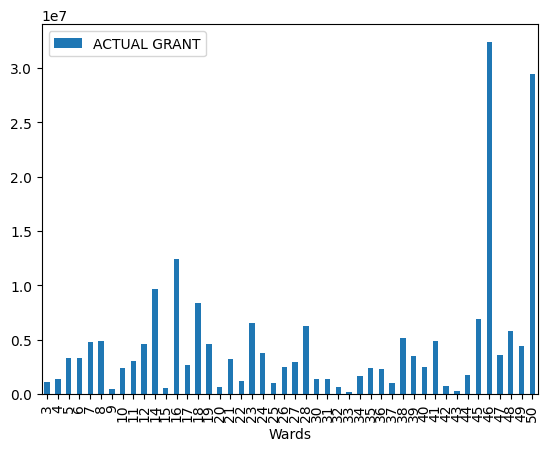

In [9]:
# Idea: Use ward data along with socioeconomic/census data to see if there's some connection between average wealth and total grants awarded
grants_licenses.groupby('Wards').agg({'ACTUAL GRANT':'sum'}).plot(kind='bar')
plt.show()

In [10]:
# Seems like the average grant and the total grants by wards are inversely correlated?